<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Build_a_Simple_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Classification using Simple Neural Network

# Step 1: Install Required Libraries

In [1]:
!pip install numpy matplotlib scikit-learn

# Step 2: Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

# Step 3: Load Dataset

In [3]:
data = fetch_olivetti_faces()

X = data.images
y = data.target

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Images shape: (400, 64, 64)
Labels shape: (400,)


# Step 4: Visualize Sample Images (Before Training)

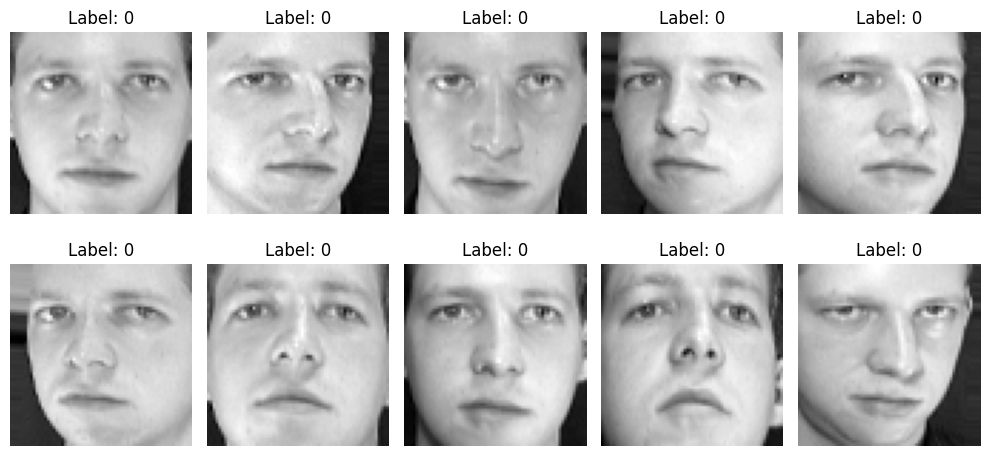

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Step 5: Data Preprocessing

In [8]:
X_flat = X.reshape(X.shape[0], -1)

num_classes = 40
y_onehot = np.eye(num_classes)[y]

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_onehot, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (320, 4096)
Test shape: (80, 4096)


# Step 6: Initialize Neural Network

In [9]:
input_size = 4096
hidden_size = 64
output_size = 40

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# Step 7: Activation Functions

In [10]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return Z > 0

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

# Step 8: Forward Propagation

In [11]:
def forward(X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    cache = (Z1, A1, Z2, A2)
    return A2, cache

# Step 9: Loss Function

In [12]:
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    return loss

# Step 10: Backpropagation

In [13]:
def backward(X, y, cache):
    global W1, b1, W2, b2

    Z1, A1, Z2, A2 = cache
    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

# Step 11: Training Loop

In [14]:
learning_rate = 0.1
epochs = 200

losses = []

for epoch in range(epochs):
    y_pred, cache = forward(X_train)
    loss = compute_loss(y_train, y_pred)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward(X_train, y_train, cache)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 3.6894
Epoch 20, Loss: 3.6598
Epoch 40, Loss: 3.6236
Epoch 60, Loss: 3.5206
Epoch 80, Loss: 3.2573
Epoch 100, Loss: 2.9880
Epoch 120, Loss: 3.0221
Epoch 140, Loss: 3.1436
Epoch 160, Loss: 2.8092
Epoch 180, Loss: 2.7868


# Step 12: Plot Training Loss

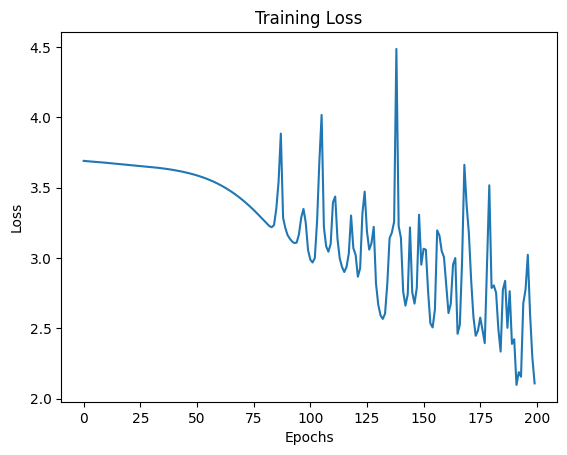

In [15]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Step 13: Prediction Function

In [16]:
def predict(X):
    y_pred, _ = forward(X)
    return np.argmax(y_pred, axis=1)

# Step 14: Evaluate Accuracy

In [17]:
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

train_preds = predict(X_train)
test_preds = predict(X_test)

print("Training Accuracy:", np.mean(train_preds == y_train_labels))
print("Testing Accuracy:", np.mean(test_preds == y_test_labels))

Training Accuracy: 0.296875
Testing Accuracy: 0.1875


# Step 15: Visualize Predictions

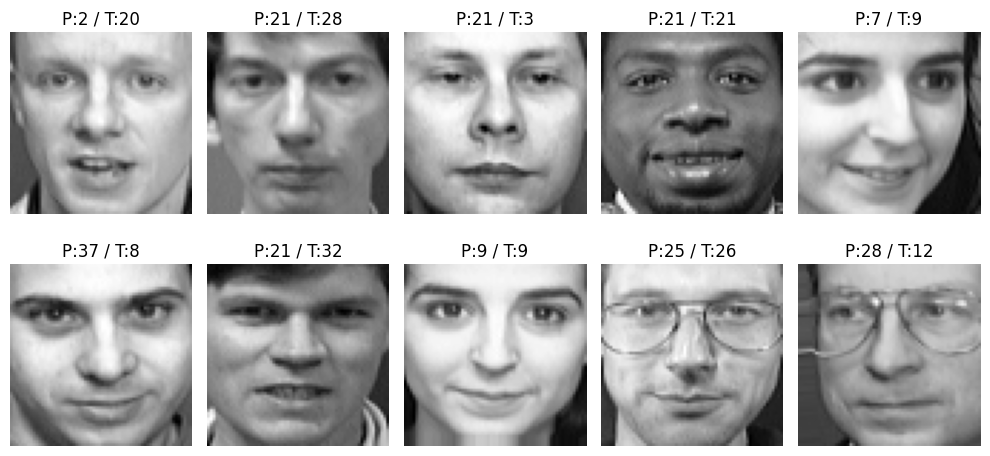

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(64, 64), cmap='gray')
    pred = test_preds[i]
    true = y_test_labels[i]
    ax.set_title(f"P:{pred} / T:{true}")
    ax.axis('off')

plt.tight_layout()
plt.show()